In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# load dataset

In [45]:
df=pd.read_csv("/Users/arjunaji/BIA ARJUN/ML/datasets/Housing.csv")

In [46]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# EDA

In [47]:
df.shape

(545, 13)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [49]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [50]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [51]:
df.describe(include='O')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [52]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


# univariate analysis and bivariate analysis

In [53]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=[object]).columns.tolist()

In [54]:
print("NUMERIC =",numerical_cols)
print("Object =",categorical_cols)

NUMERIC = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Object = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


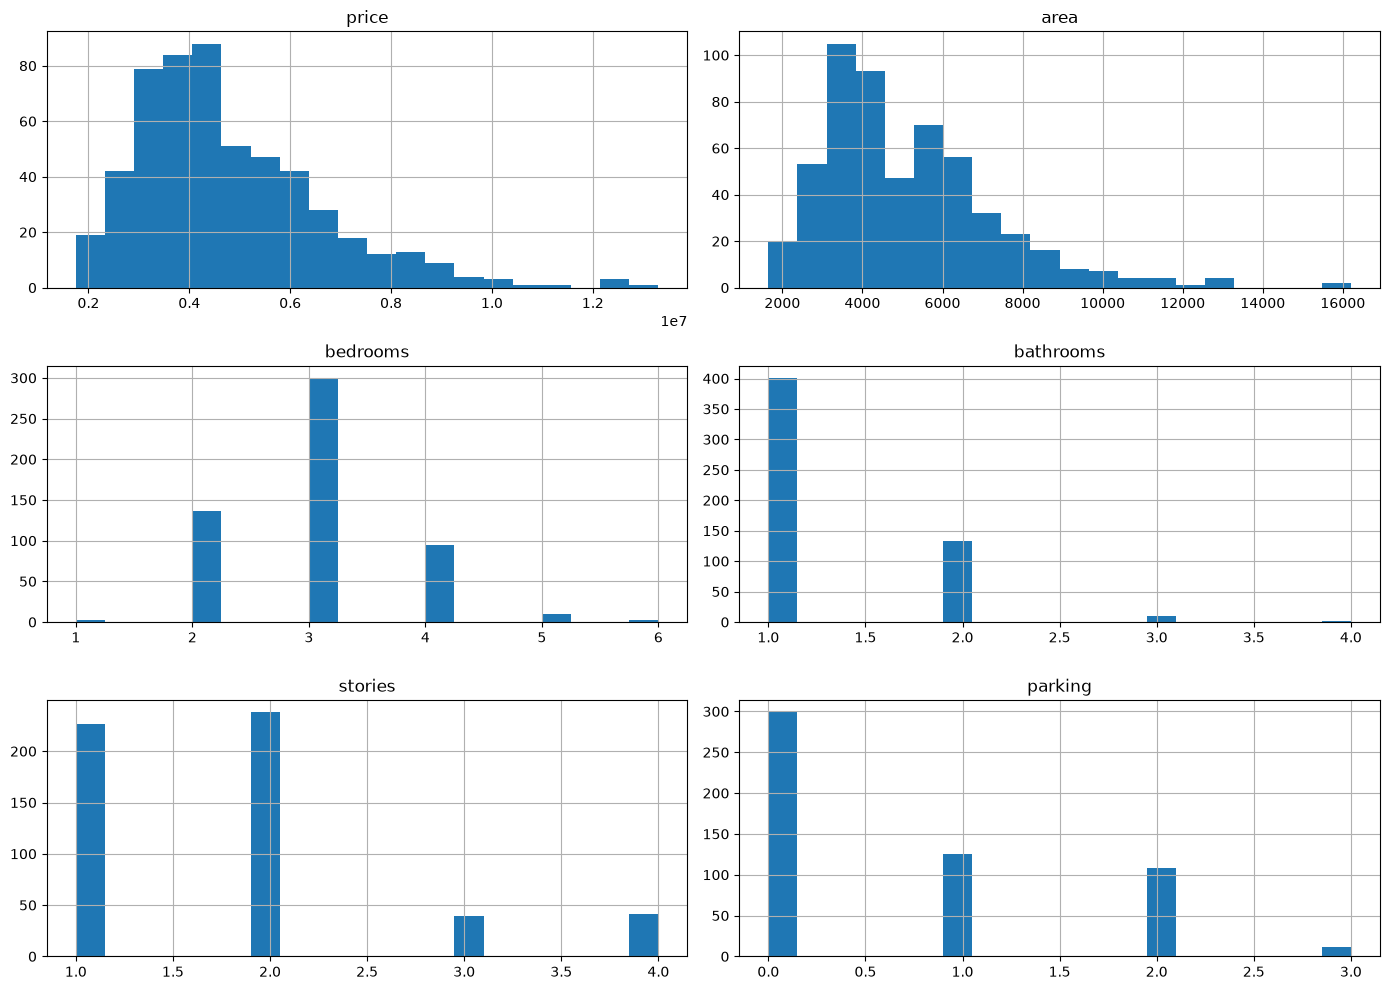

In [55]:
if numerical_cols:
    df[numerical_cols].hist(figsize=(14,10),bins=20)
    plt.tight_layout()
    plt.show()

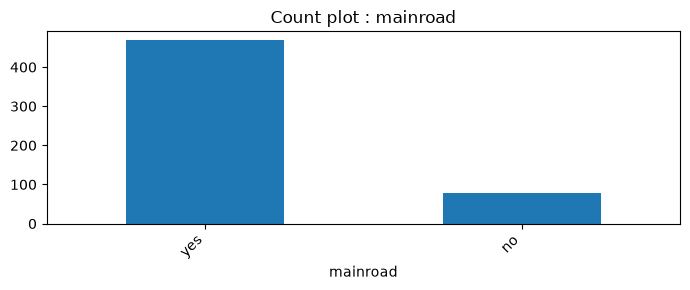

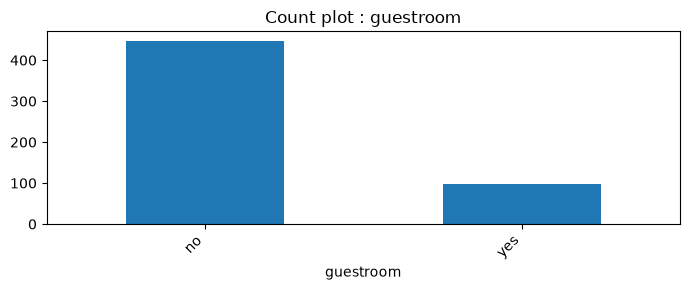

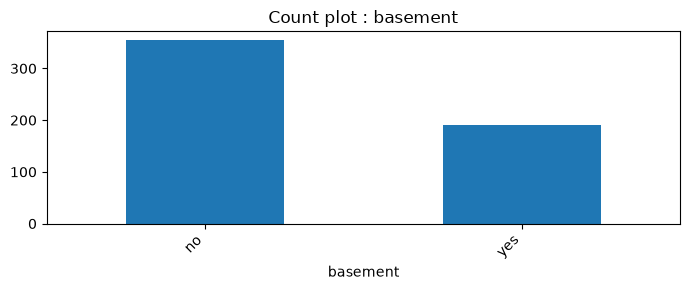

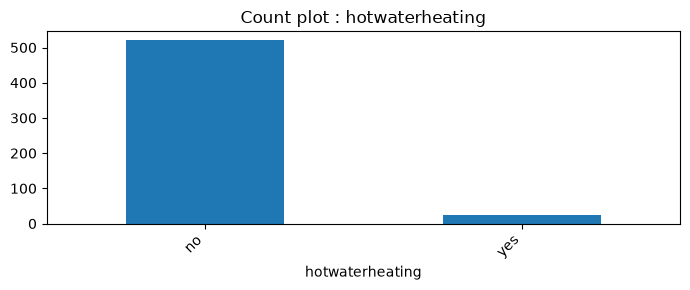

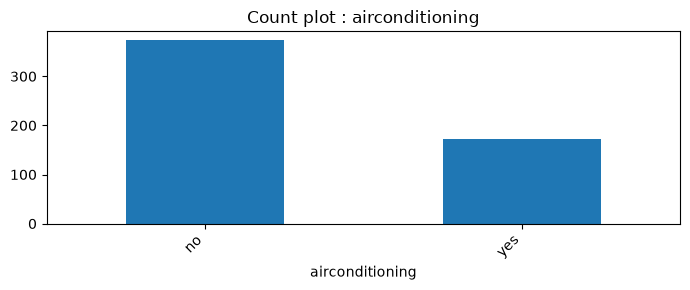

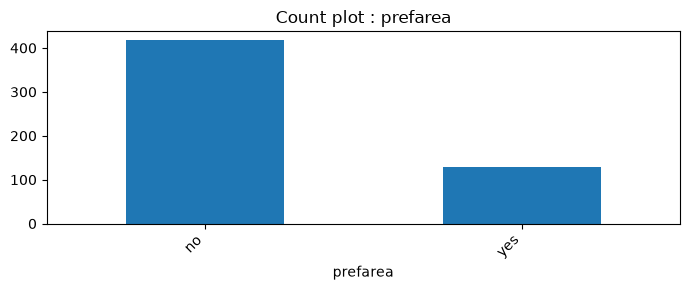

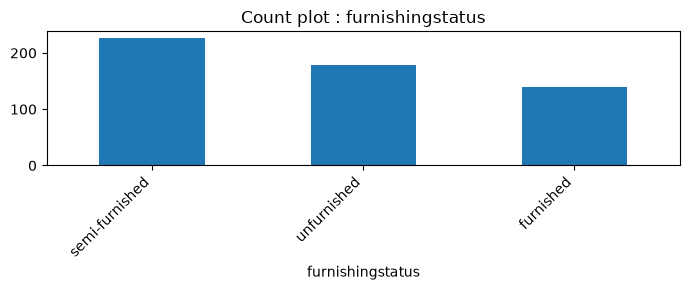

In [56]:
for col in categorical_cols:
    plt.figure(figsize=(7,3))
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Count plot : {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# bivarient analysis(hw)


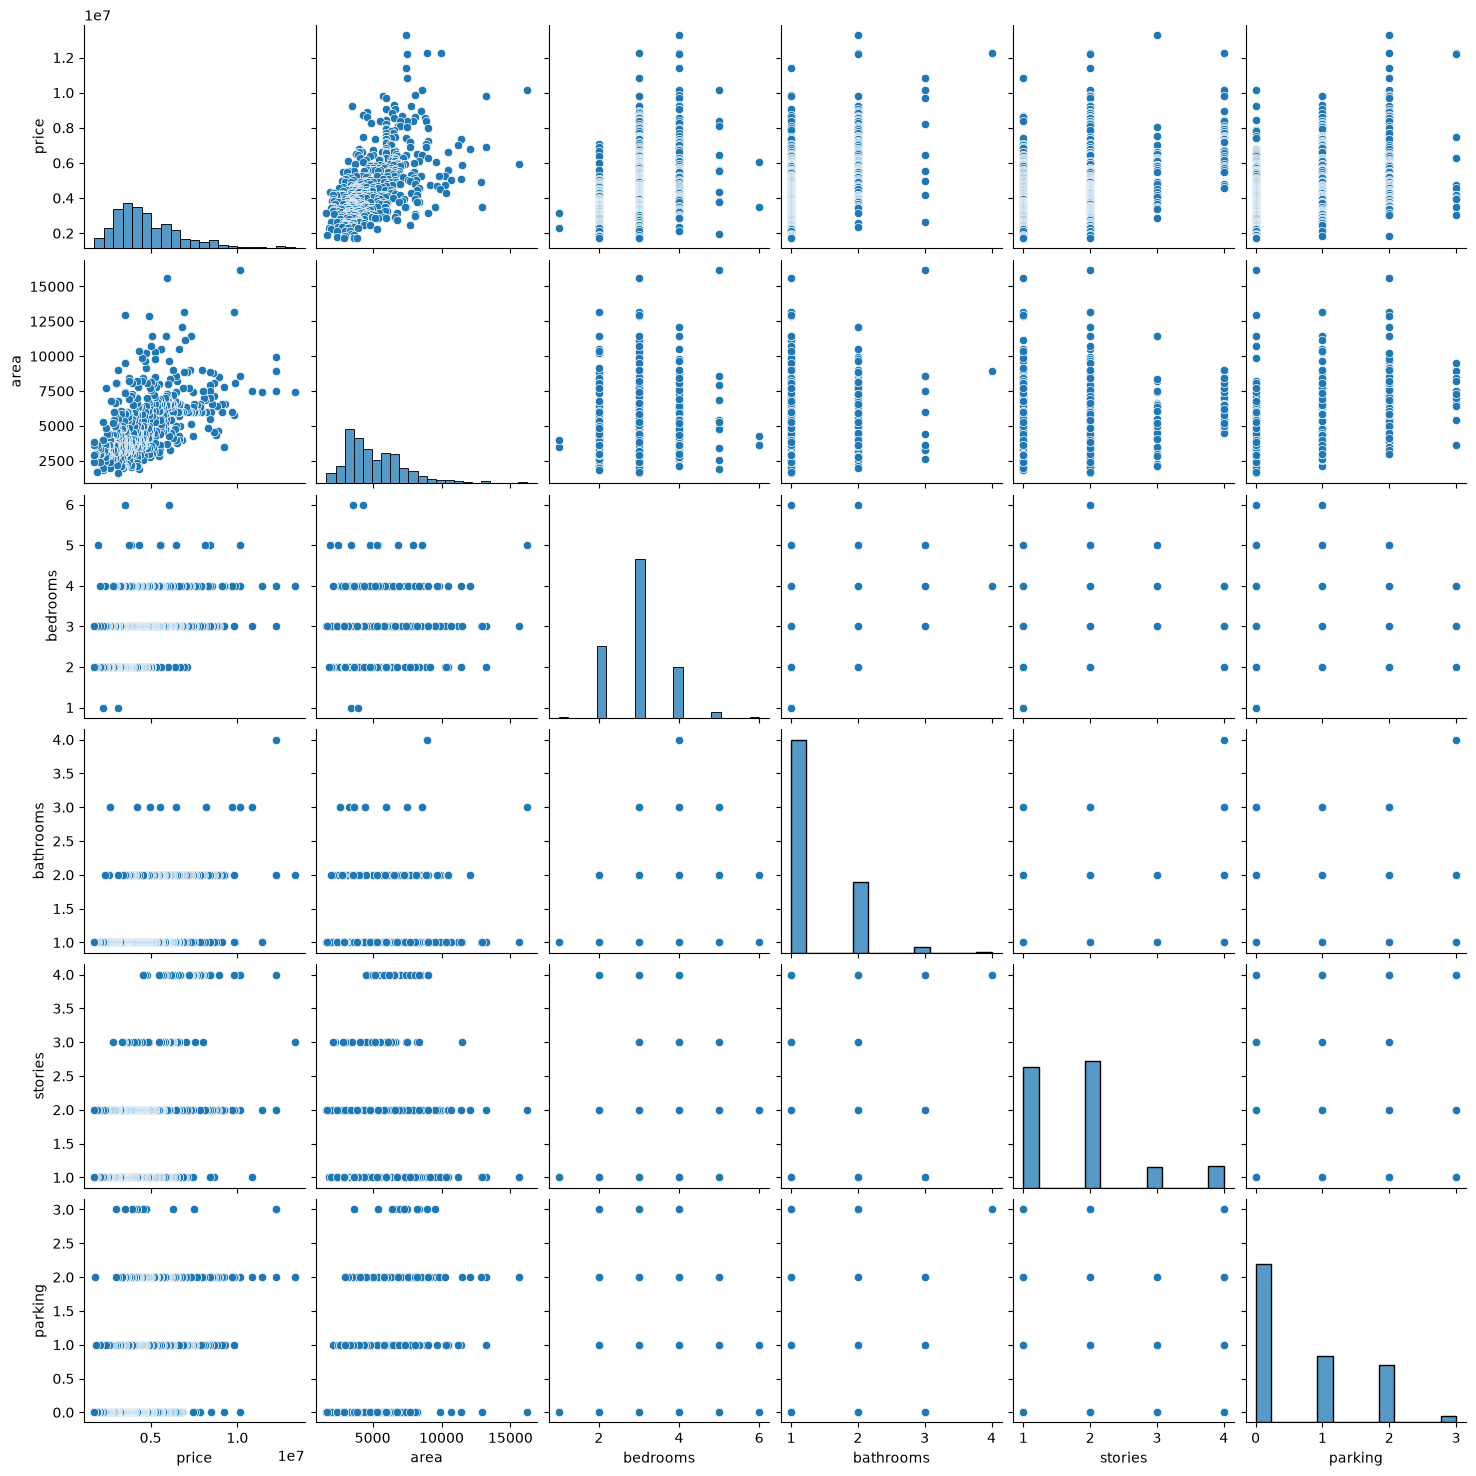

In [57]:
sns.pairplot(df)

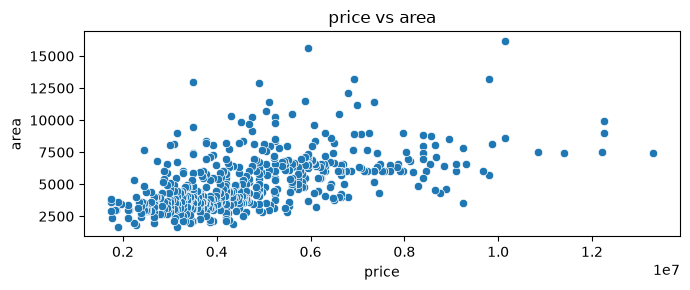

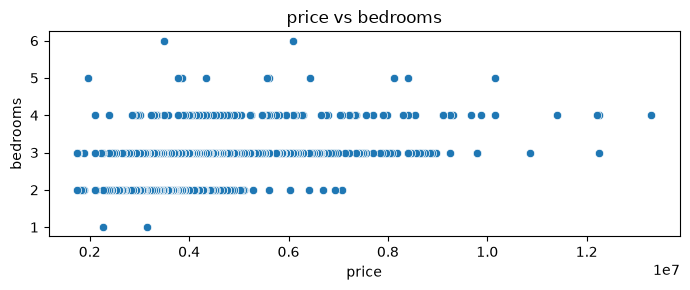

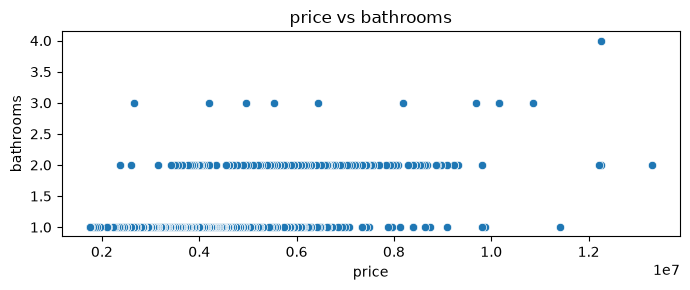

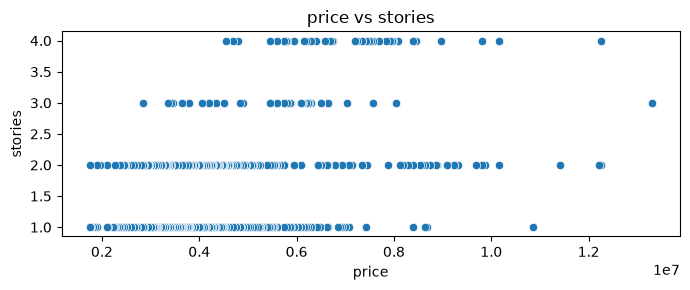

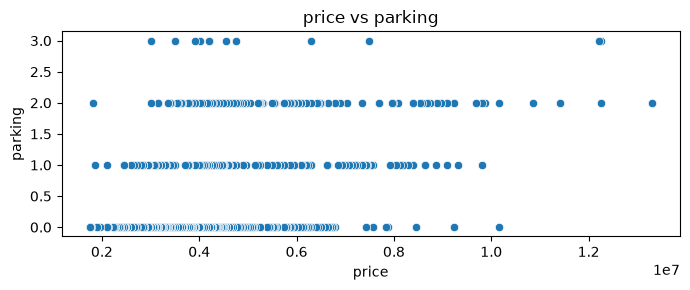

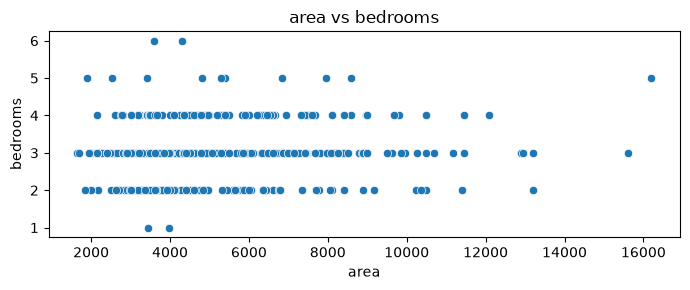

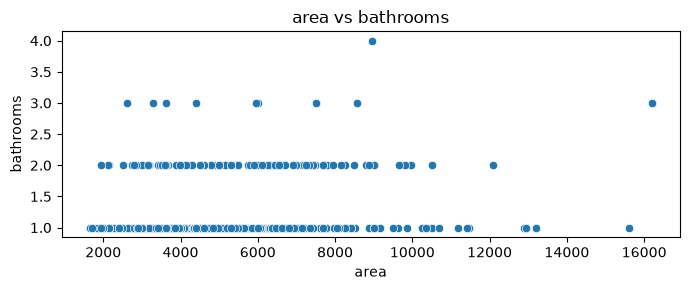

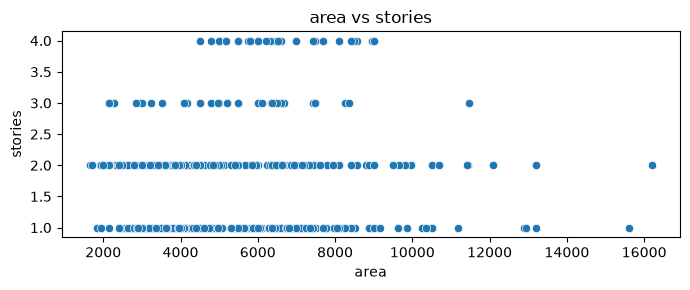

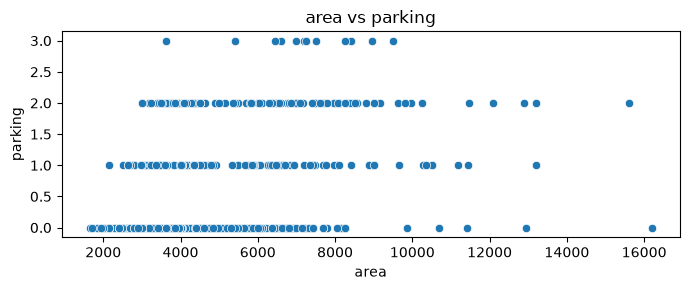

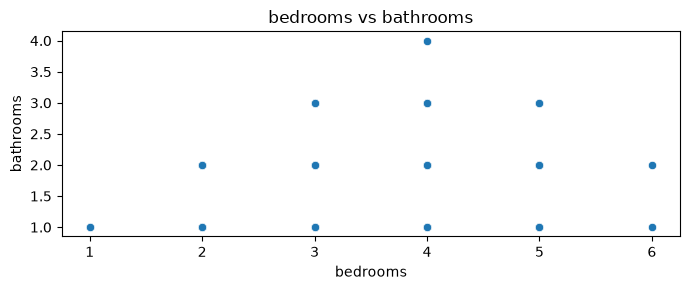

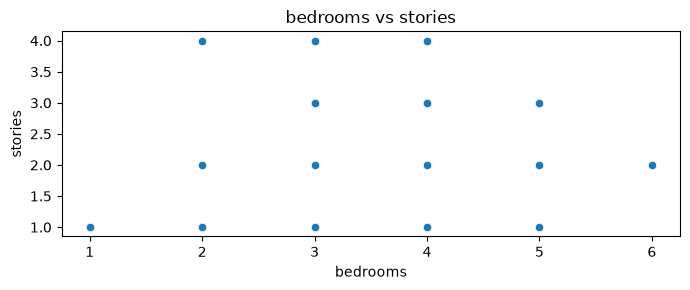

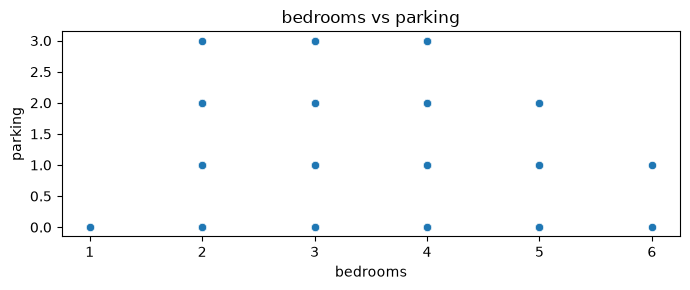

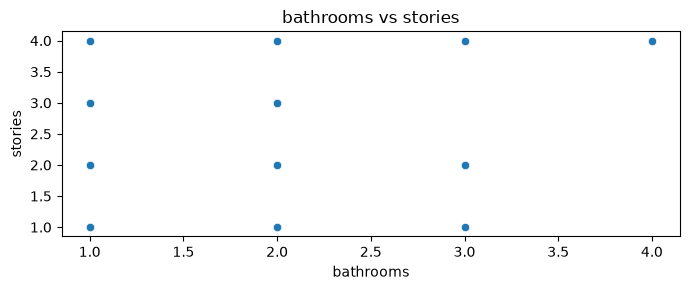

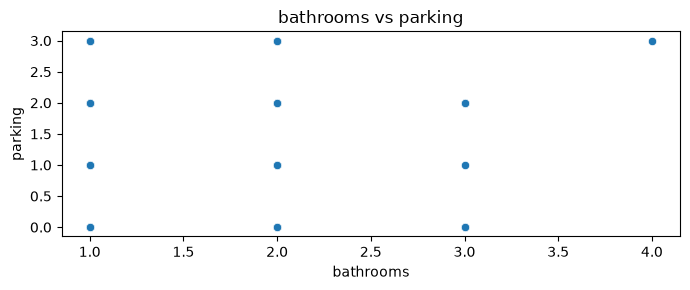

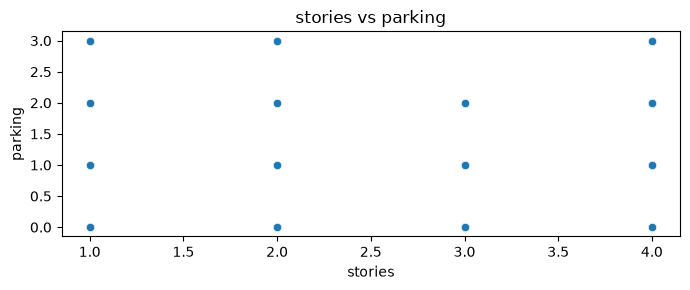

In [58]:
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):

        x = numerical_cols[i]
        y = numerical_cols[j]

        plt.figure(figsize=(7,3))
        sns.scatterplot(data=df, x=x, y=y)

        plt.title(f'{x} vs {y}')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()

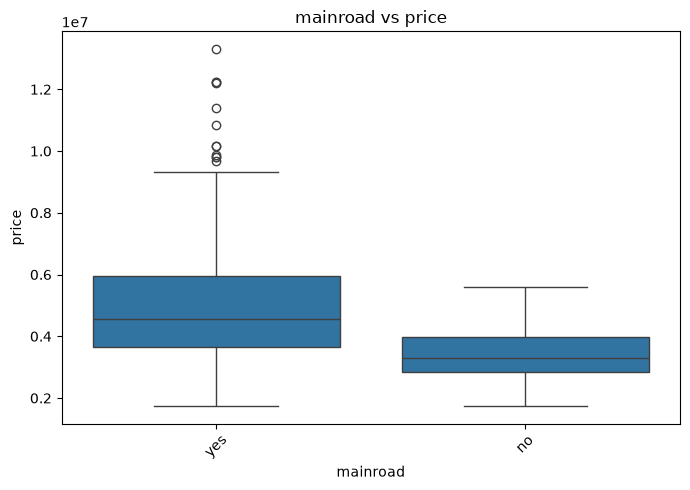

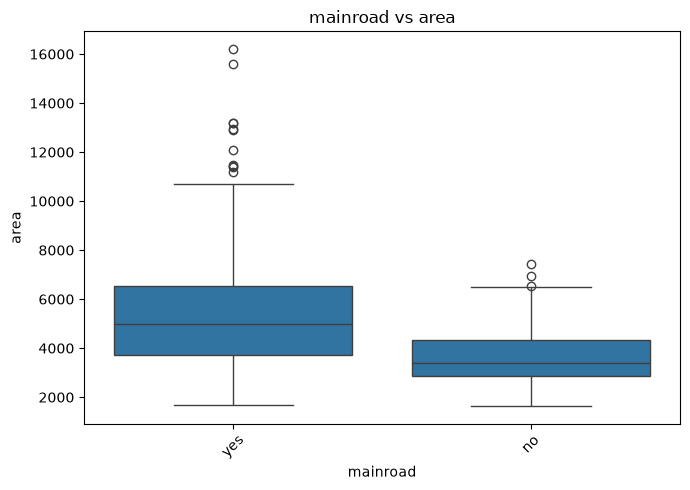

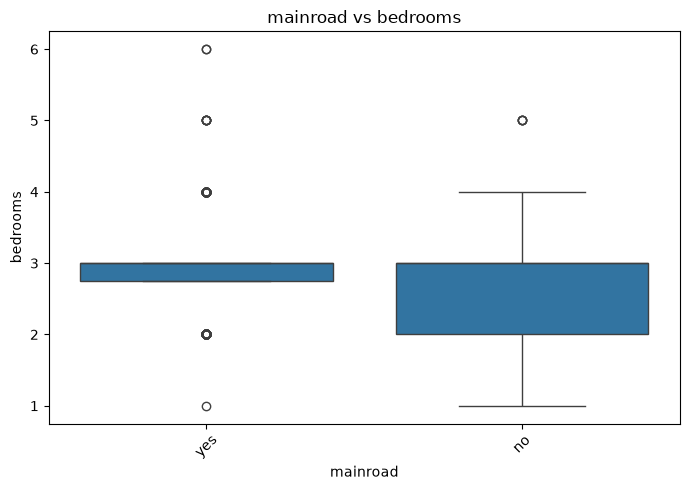

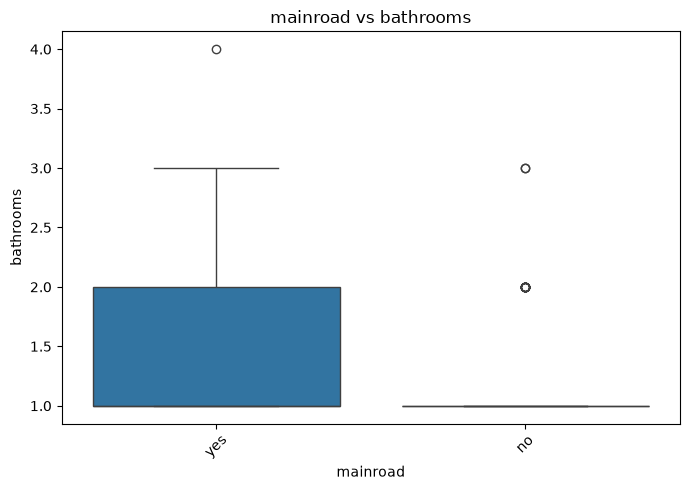

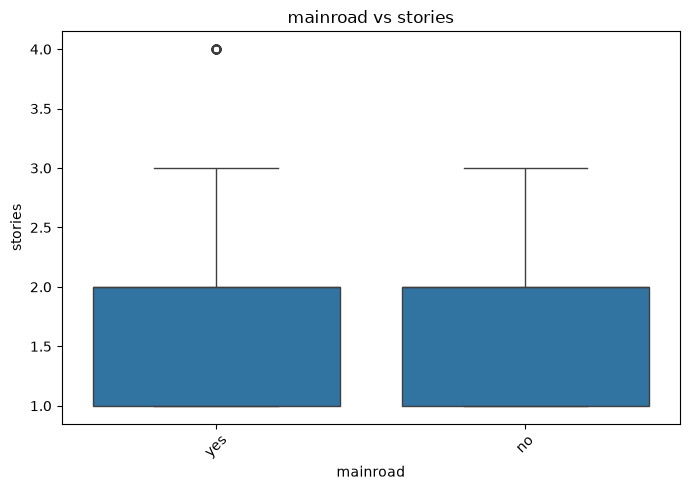

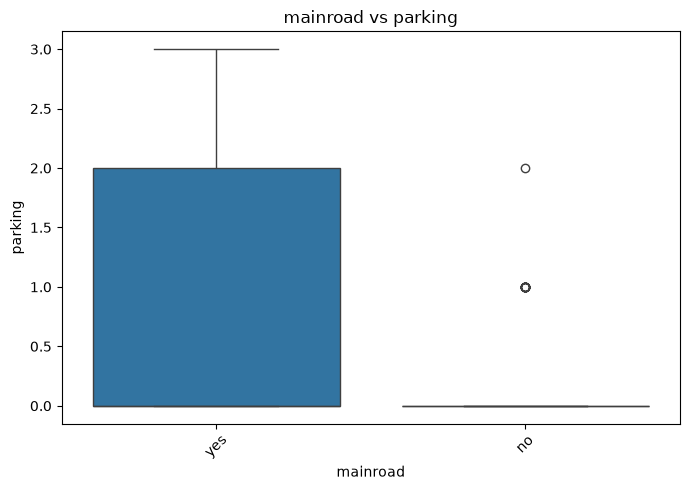

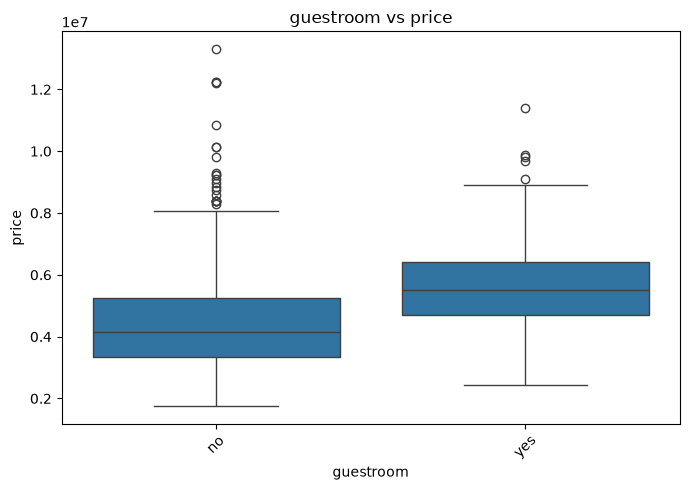

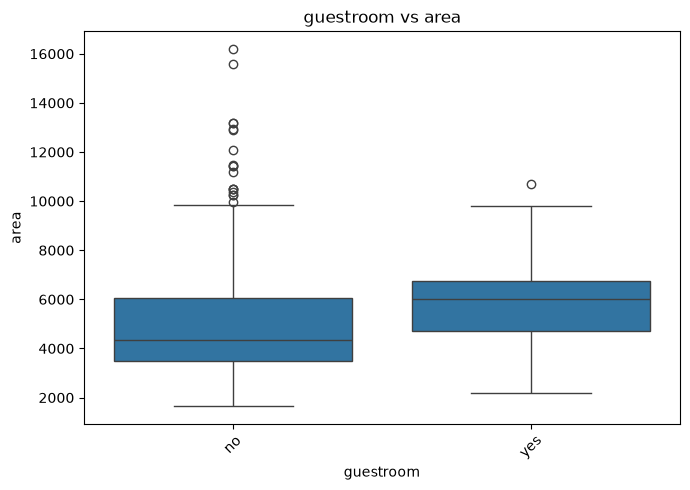

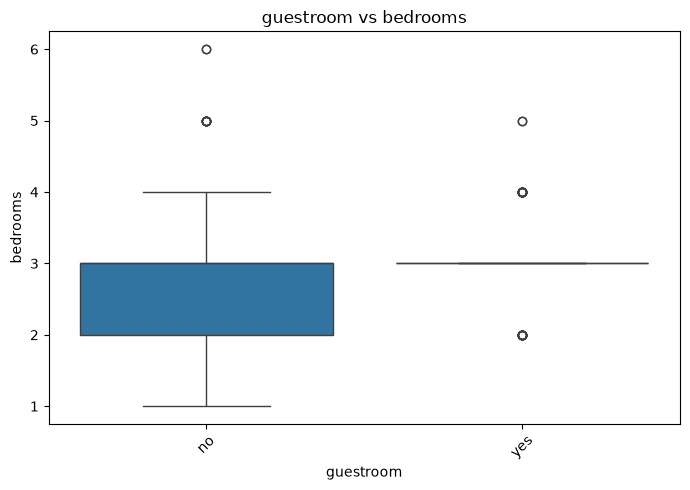

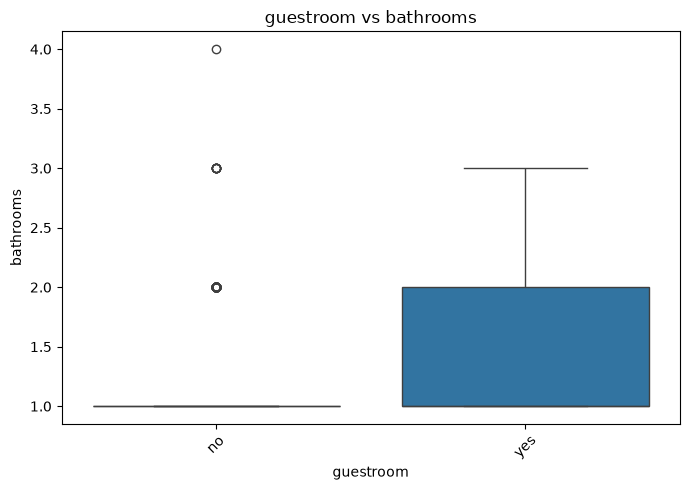

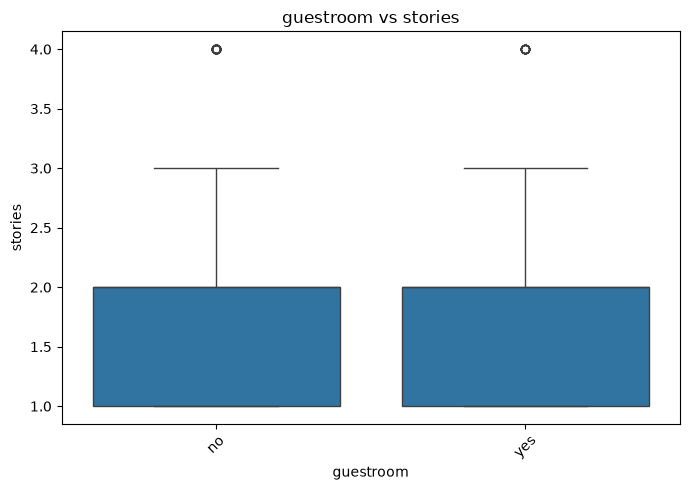

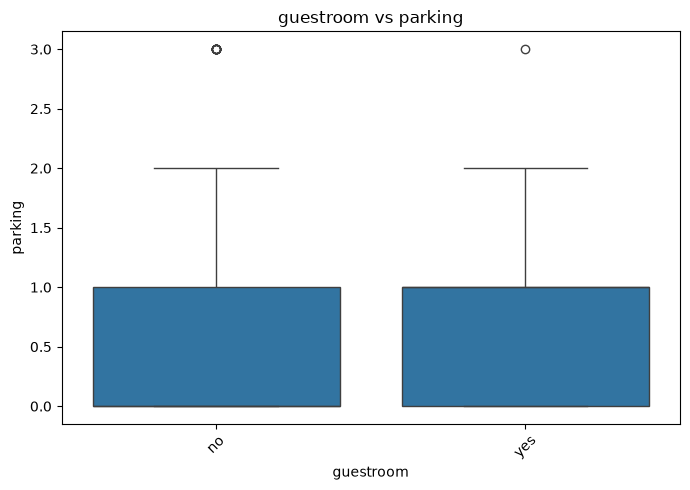

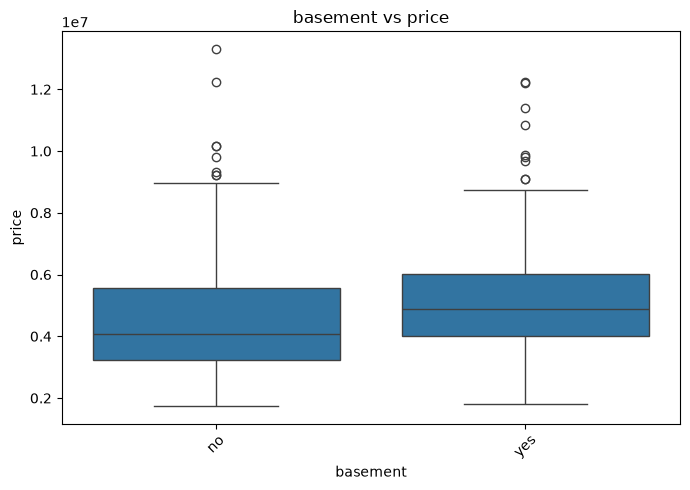

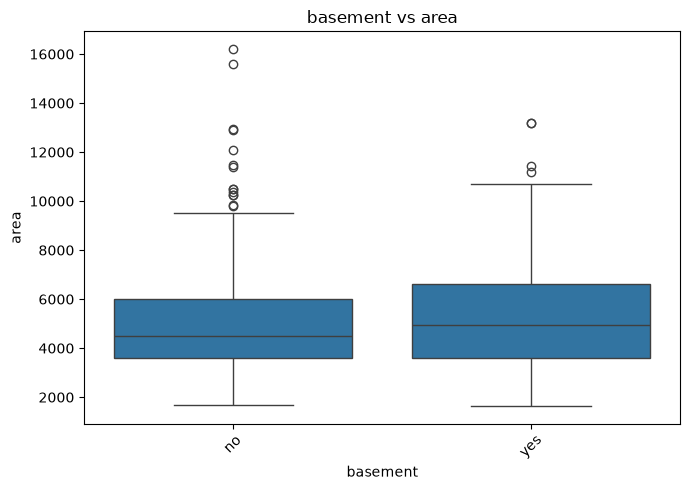

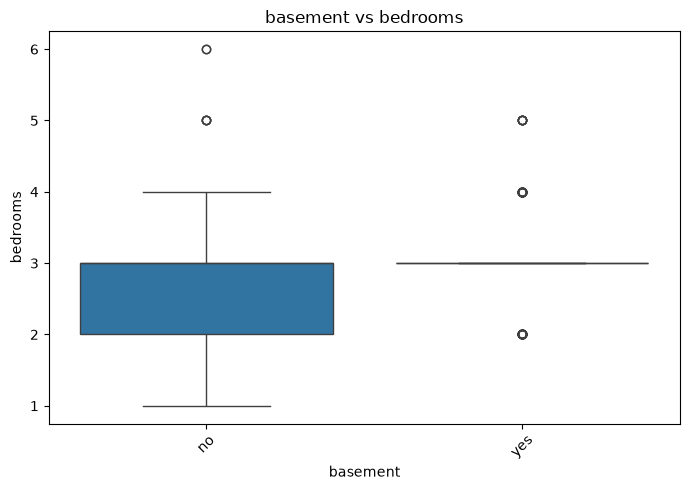

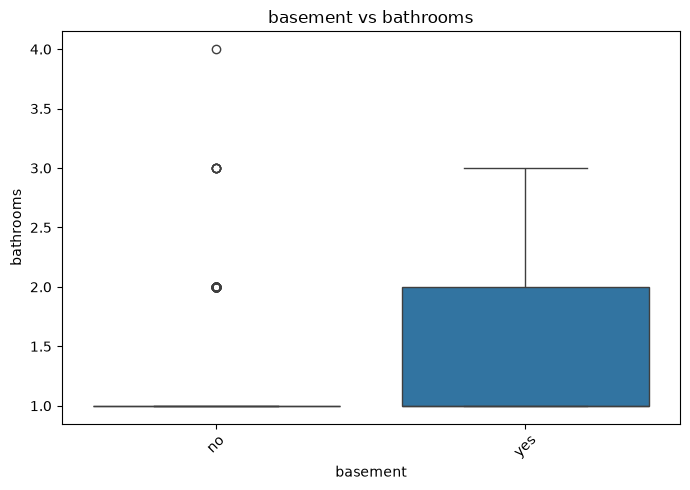

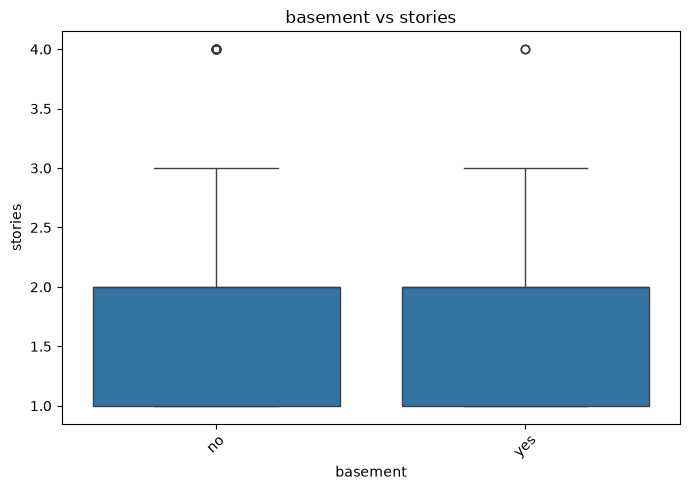

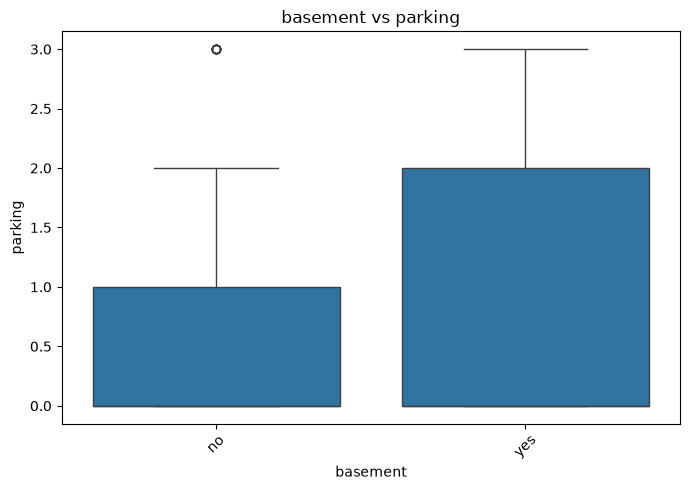

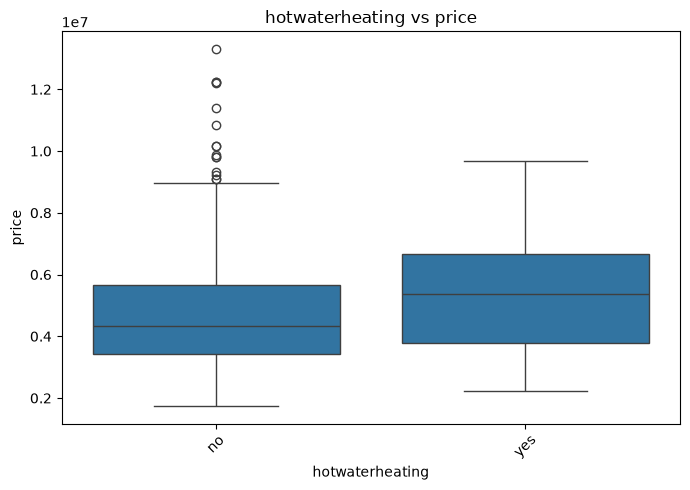

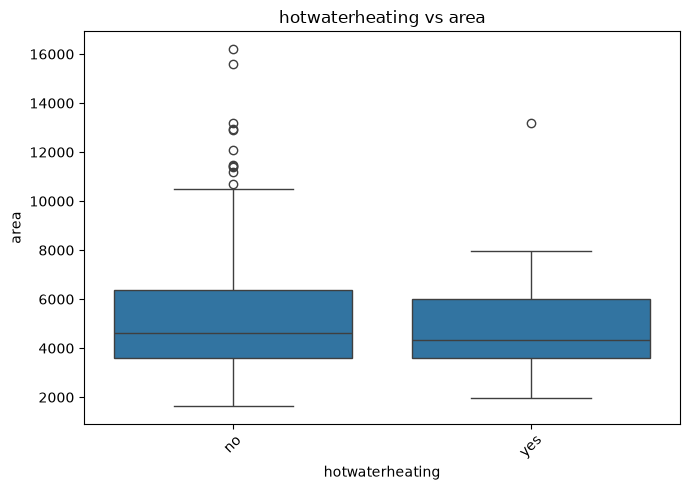

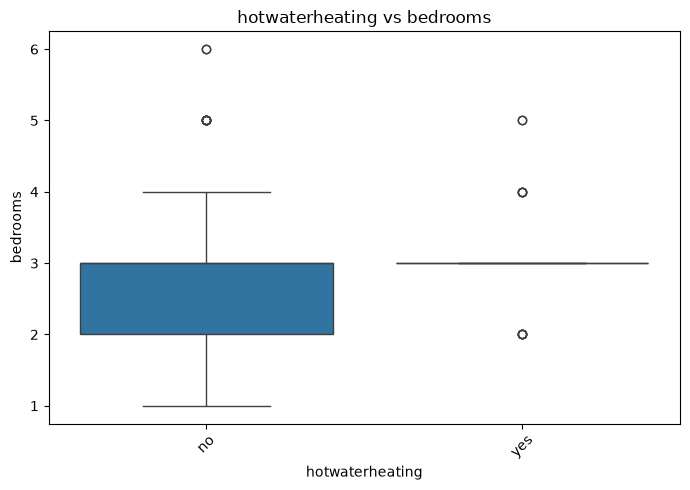

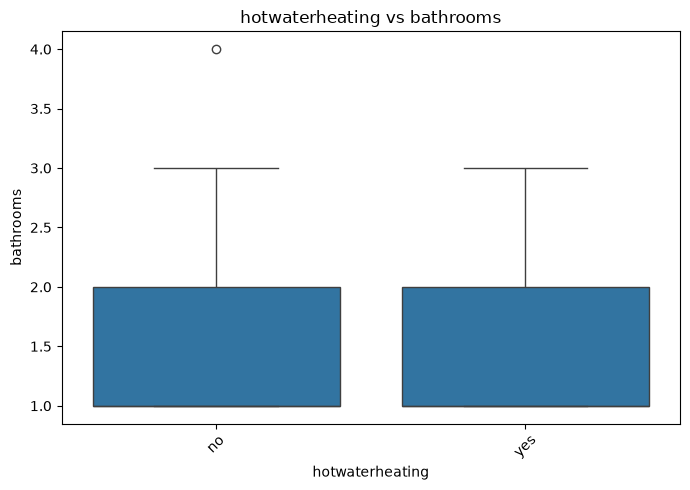

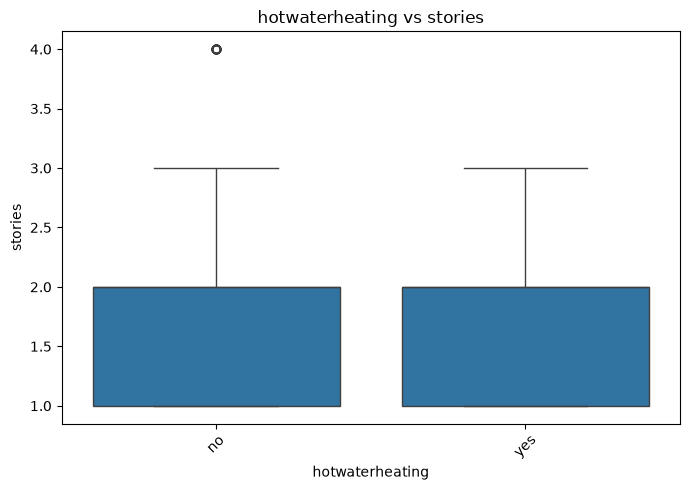

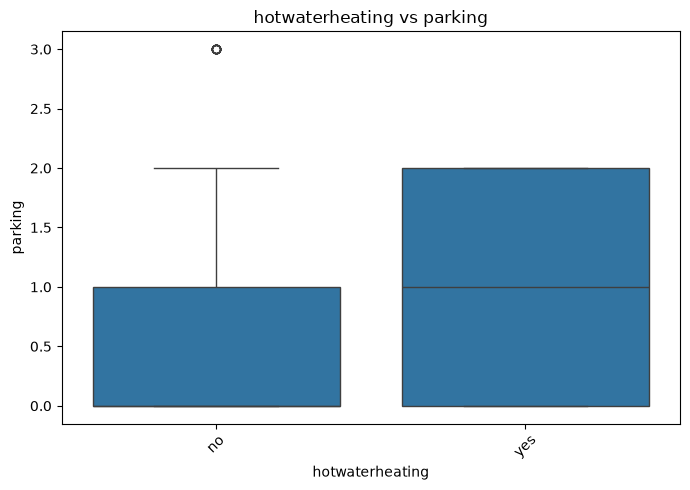

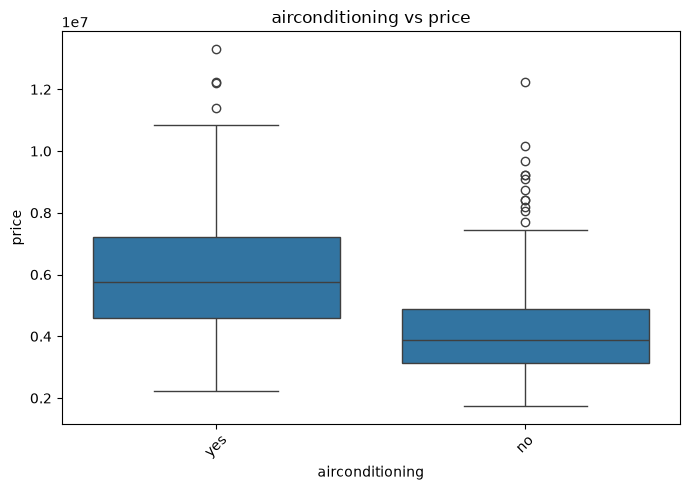

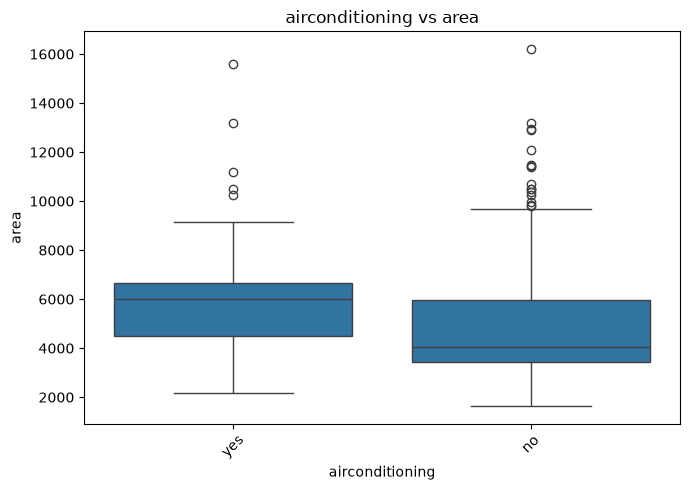

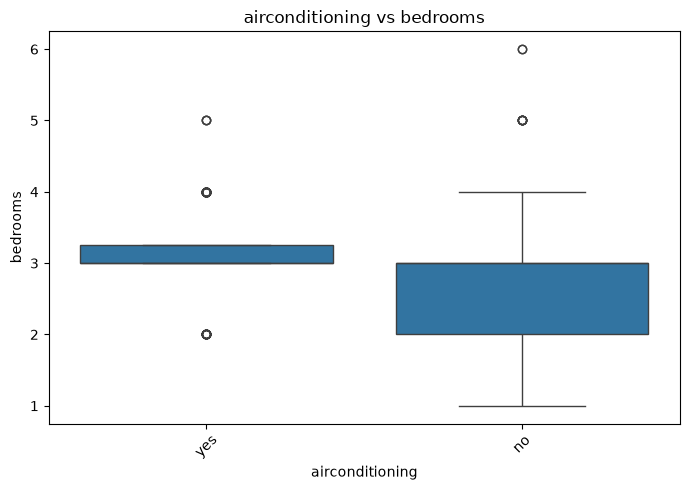

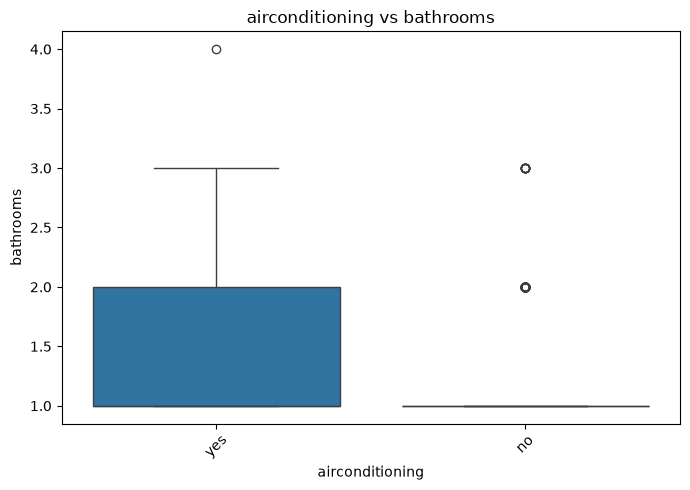

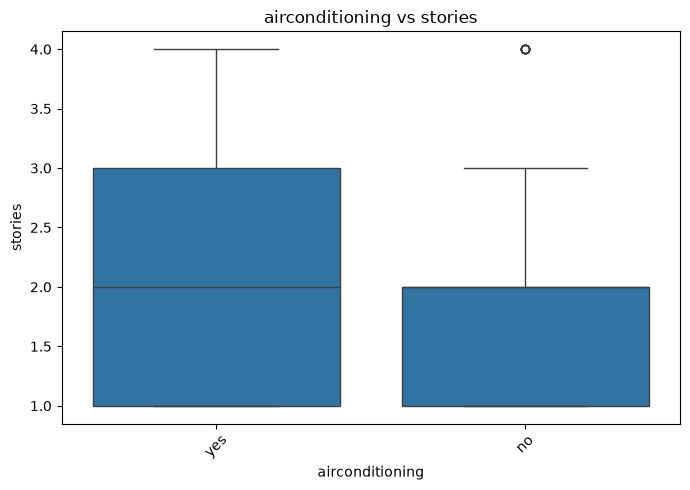

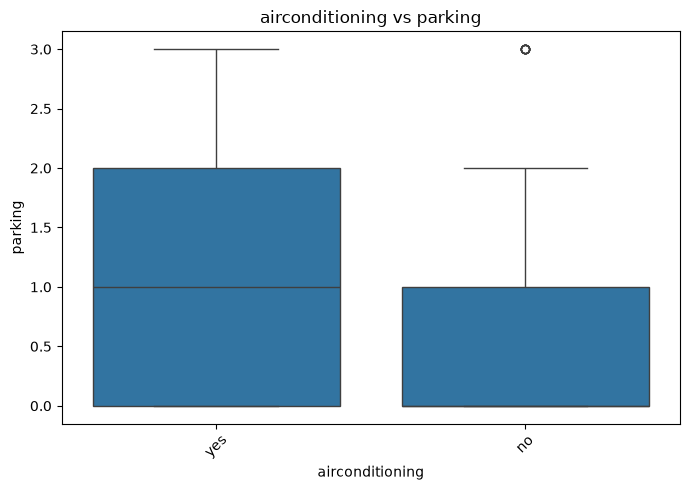

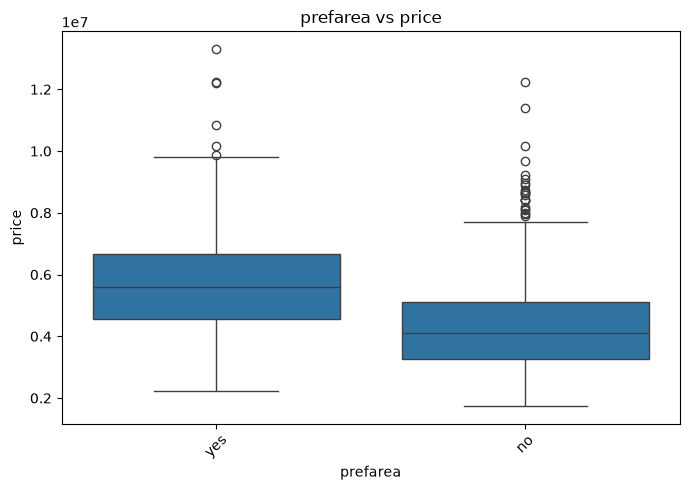

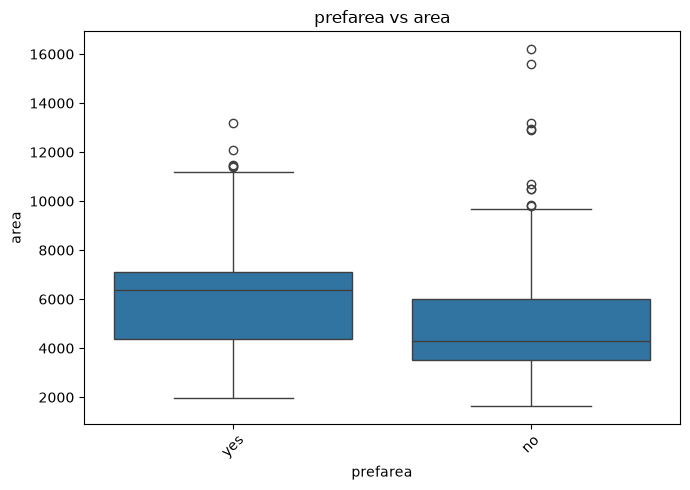

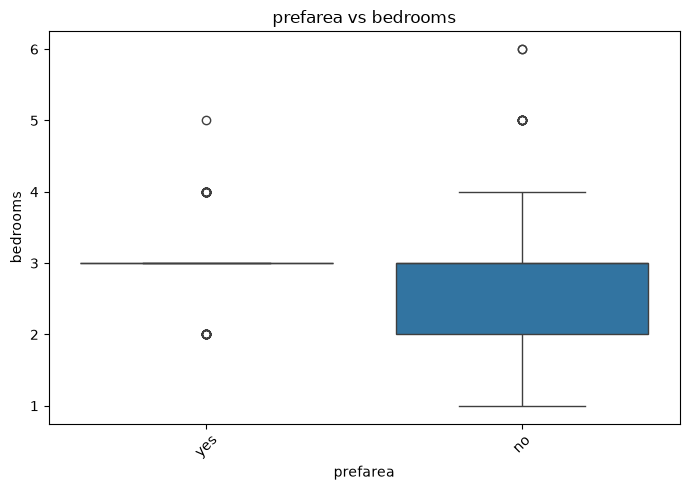

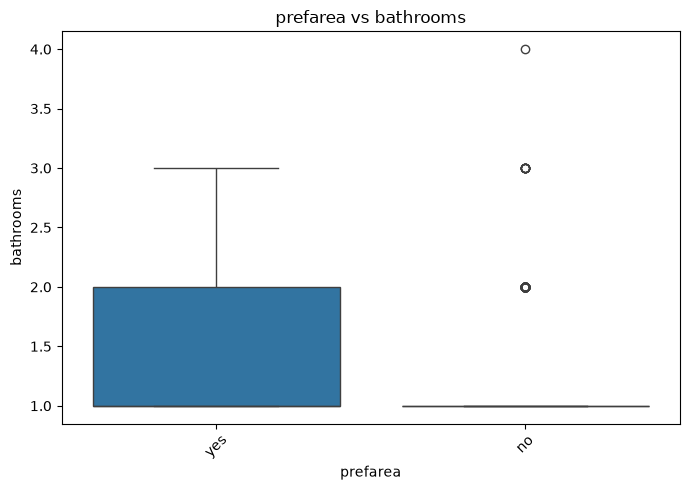

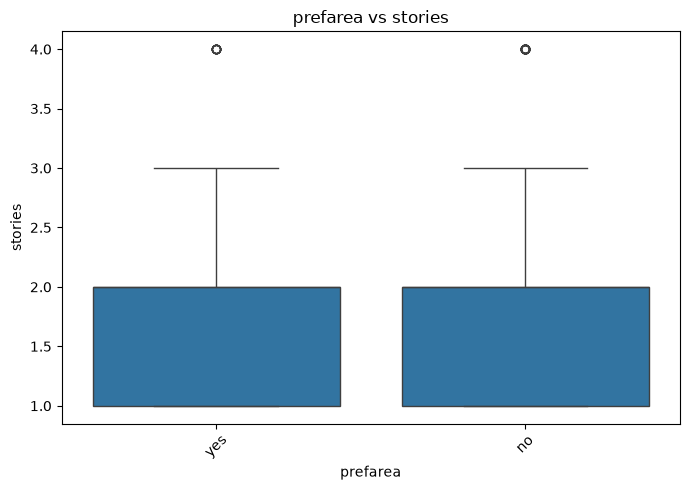

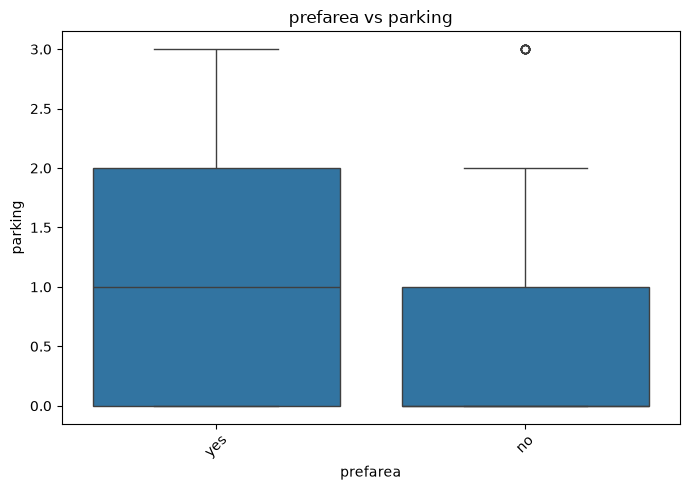

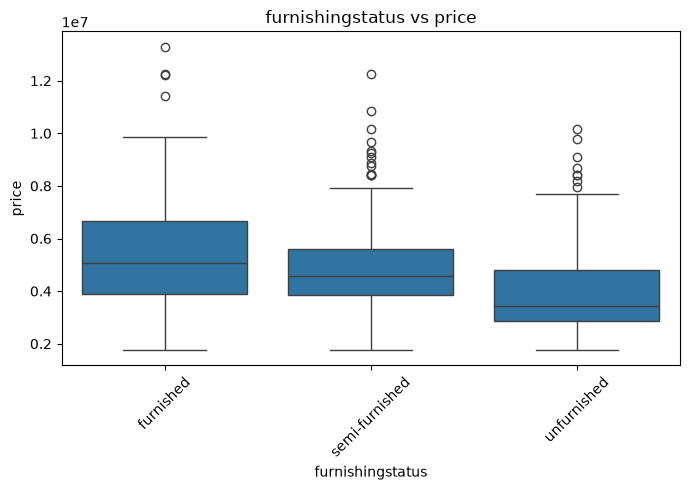

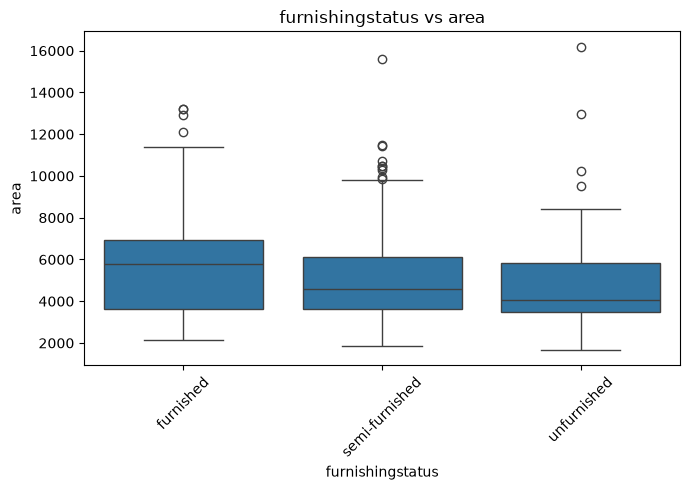

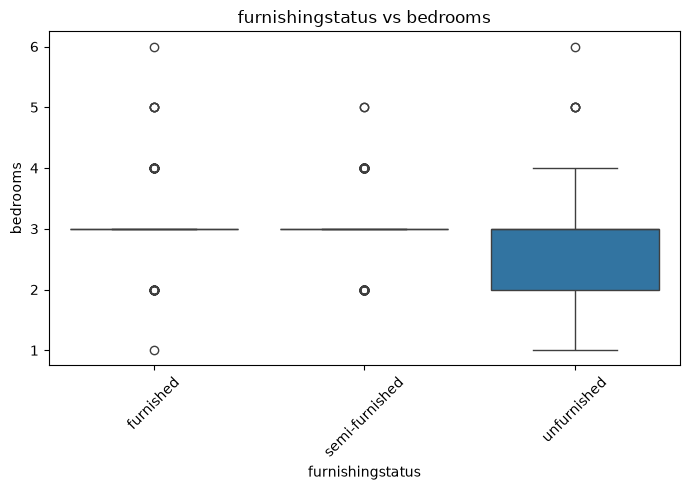

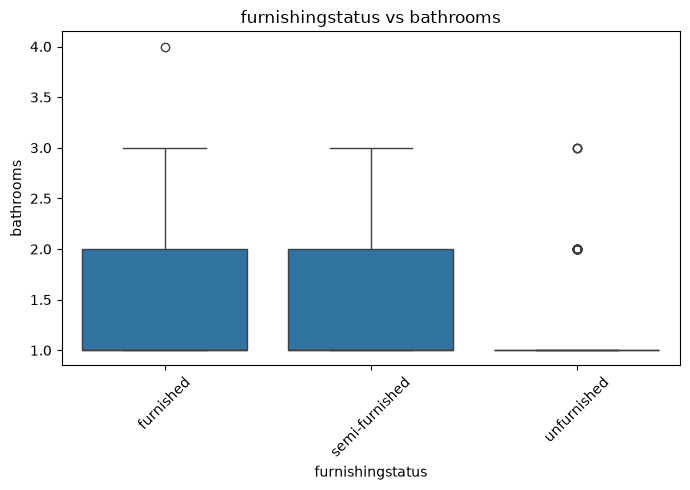

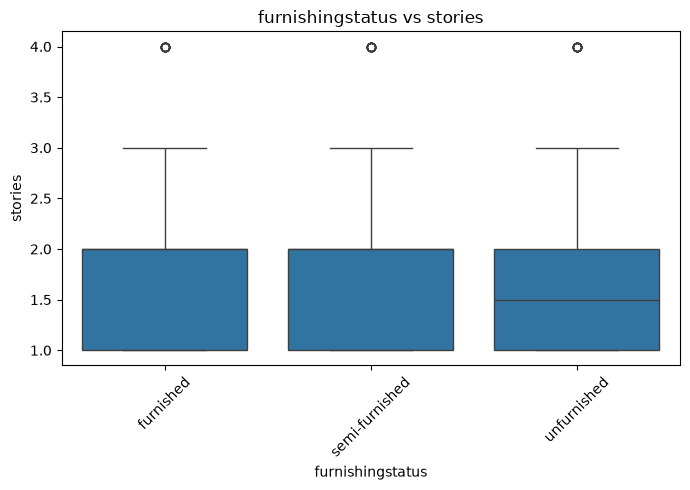

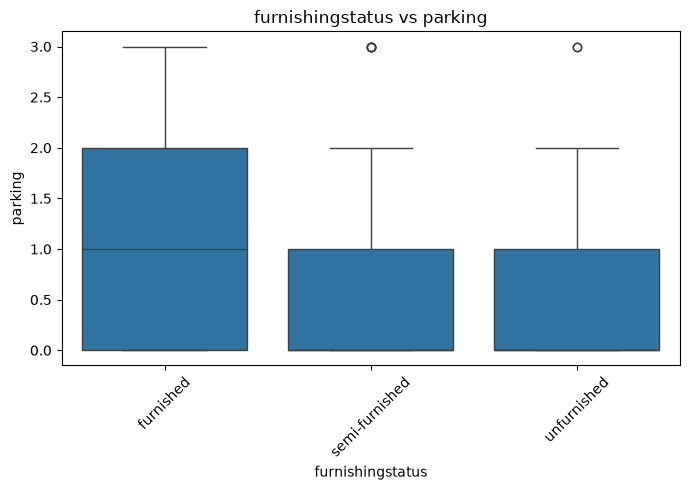

In [59]:
for cat in categorical_cols:
    for num in numerical_cols:

        plt.figure(figsize=(7,5))
        sns.boxplot(data=df, x=cat, y=num)

        plt.title(f'{cat} vs {num}')
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

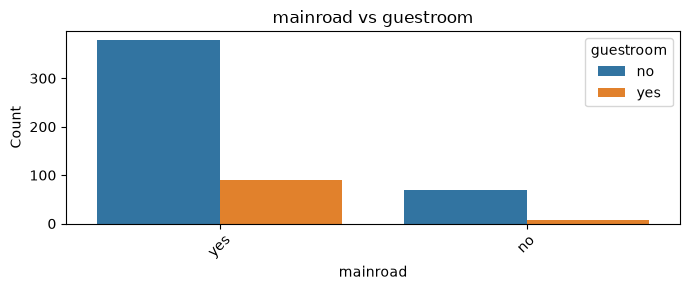

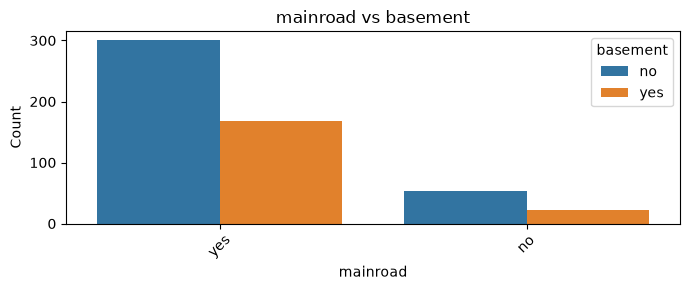

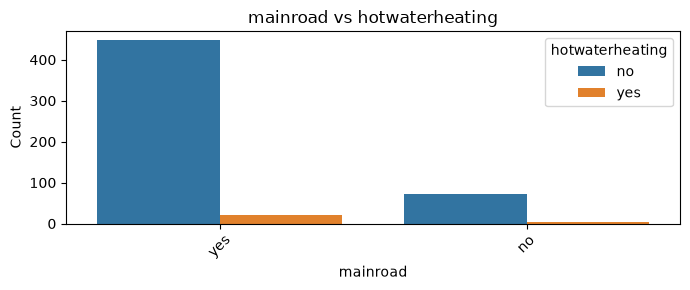

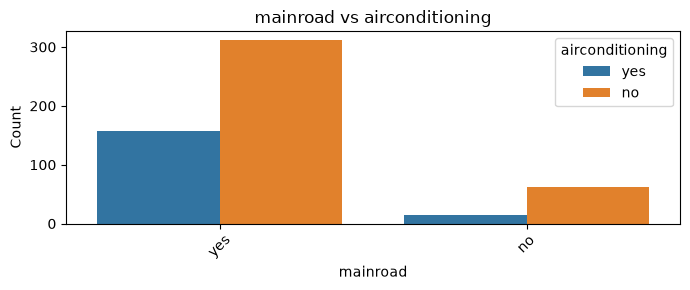

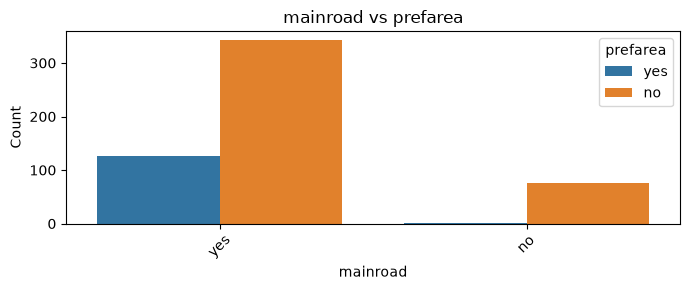

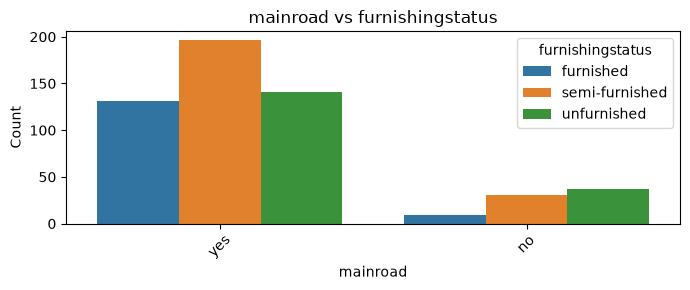

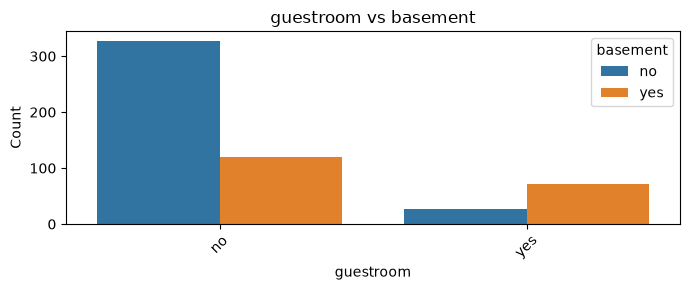

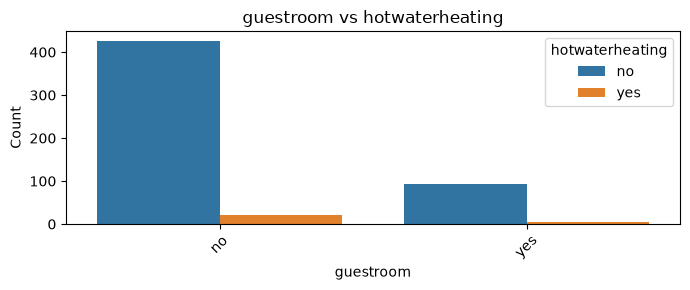

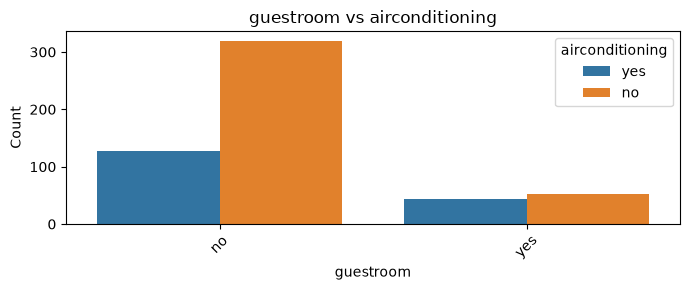

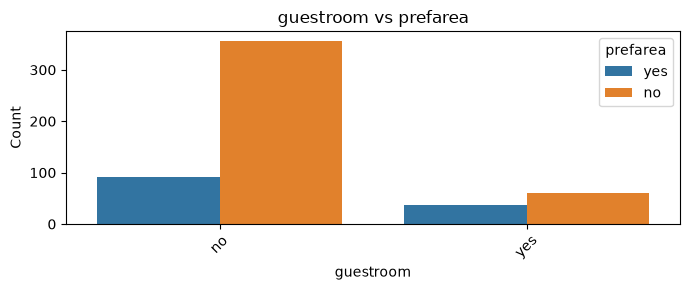

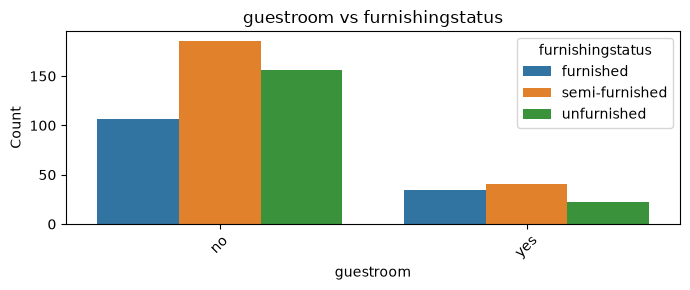

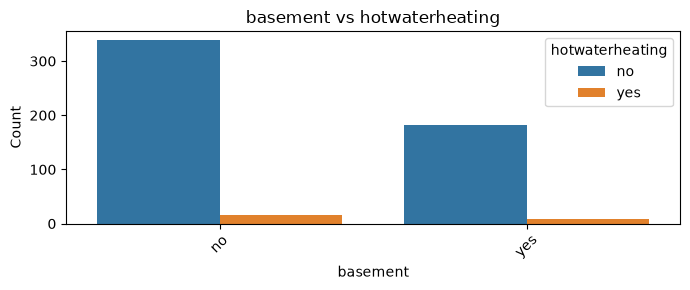

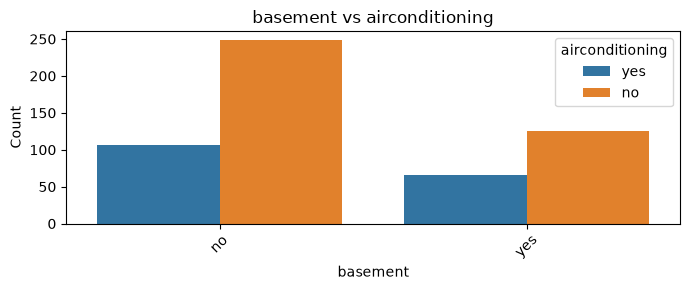

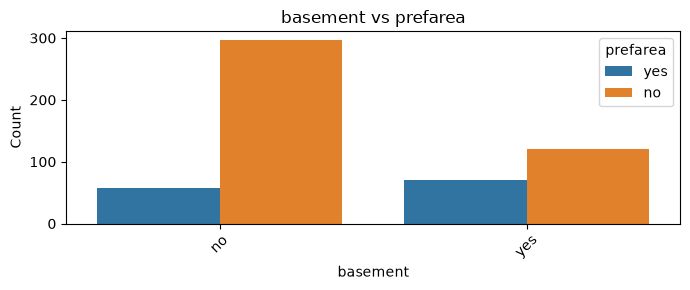

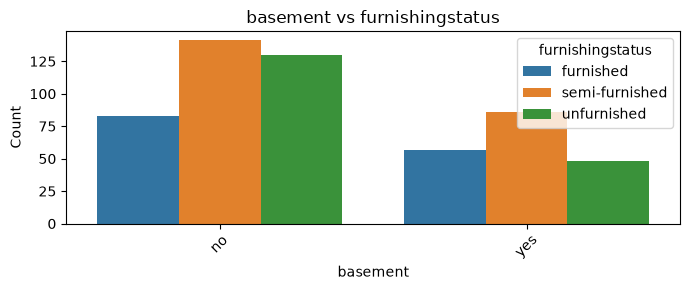

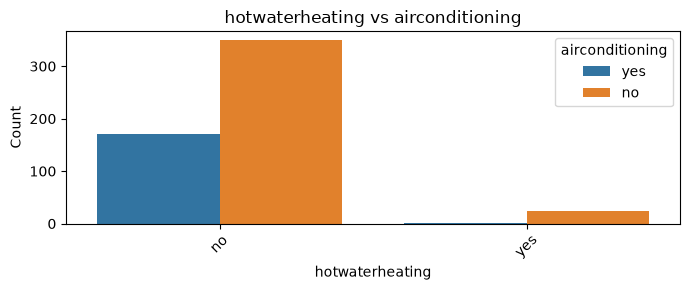

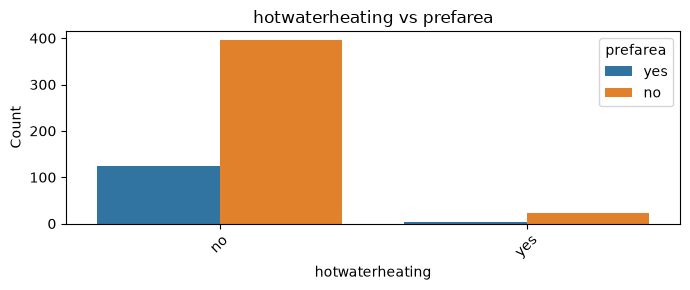

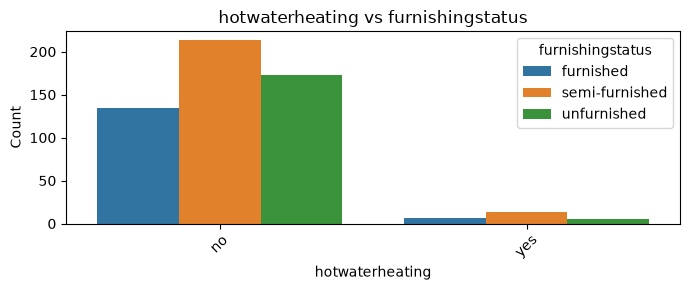

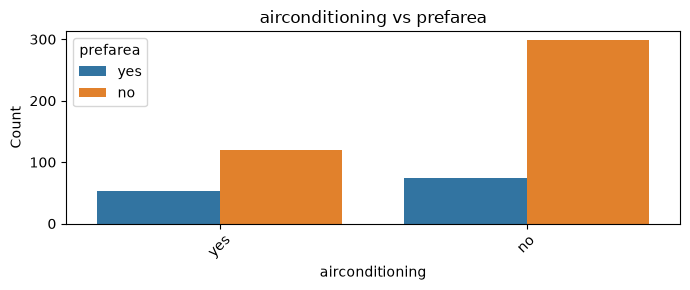

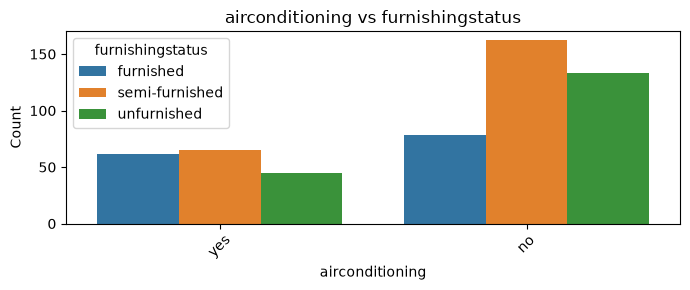

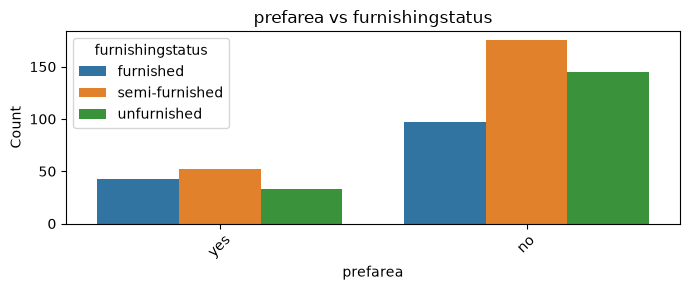

In [60]:
for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):

        x = categorical_cols[i]
        y = categorical_cols[j]

        plt.figure(figsize=(7,3))
        sns.countplot(data=df, x=x, hue=y)

        plt.title(f'{x} vs {y}')
        plt.xlabel(x)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [61]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

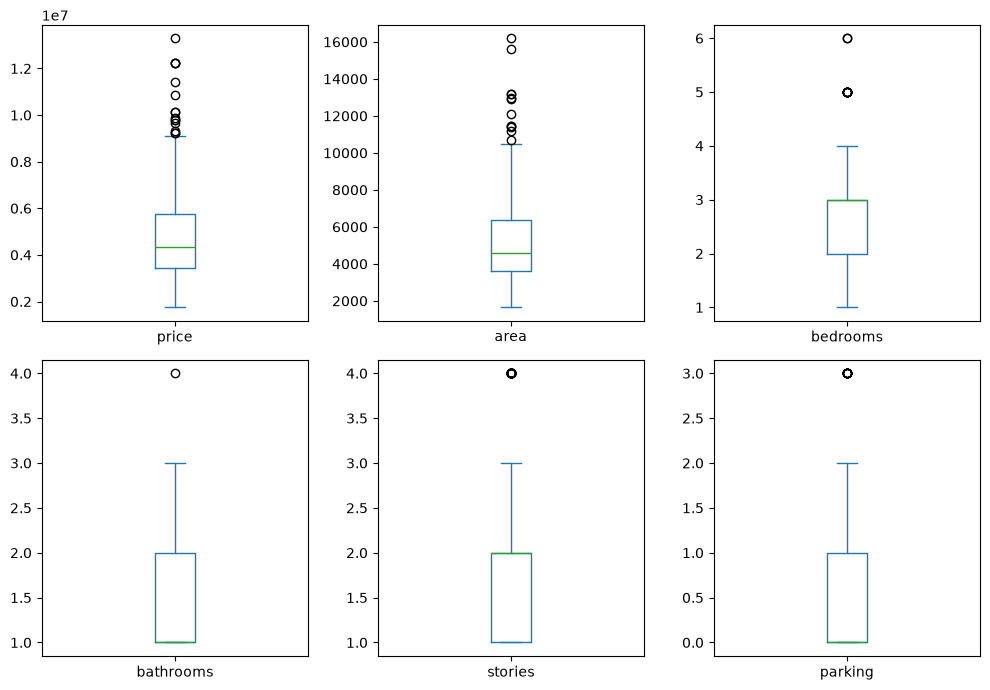

In [62]:
if numerical_cols:
    df[numerical_cols].plot(kind="box",subplots=True,layout=(2,3), figsize=(10,7))
    plt.tight_layout()
    plt.show()

# feature engineering

In [63]:
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [64]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [65]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [66]:
categorical_copy= categorical_cols.copy()

In [67]:
categorical_copy.remove('furnishingstatus')

In [68]:
categorical_copy

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea']

In [69]:
df[categorical_copy]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,yes,no,no,no,yes,yes
1,yes,no,no,no,yes,no
2,yes,no,yes,no,no,yes
3,yes,no,yes,no,yes,yes
4,yes,yes,yes,no,yes,no
...,...,...,...,...,...,...
540,yes,no,yes,no,no,no
541,no,no,no,no,no,no
542,yes,no,no,no,no,no
543,no,no,no,no,no,no


In [71]:
# encoding
#custom encoding
custom_mapping = {'yes':1,'no':0}
for cat in categorical_copy:
    df[cat]=df[cat].map(custom_mapping)
df['furnishingstatus']=df['furnishingstatus'].map({'furnished':3,'semi-furnished':2,'unfurnished':1})

In [72]:
df[categorical_cols]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1,0,0,0,1,1,3
1,1,0,0,0,1,0,3
2,1,0,1,0,0,1,2
3,1,0,1,0,1,1,3
4,1,1,1,0,1,0,3
...,...,...,...,...,...,...,...
540,1,0,1,0,0,0,1
541,0,0,0,0,0,0,2
542,1,0,0,0,0,0,1
543,0,0,0,0,0,0,3


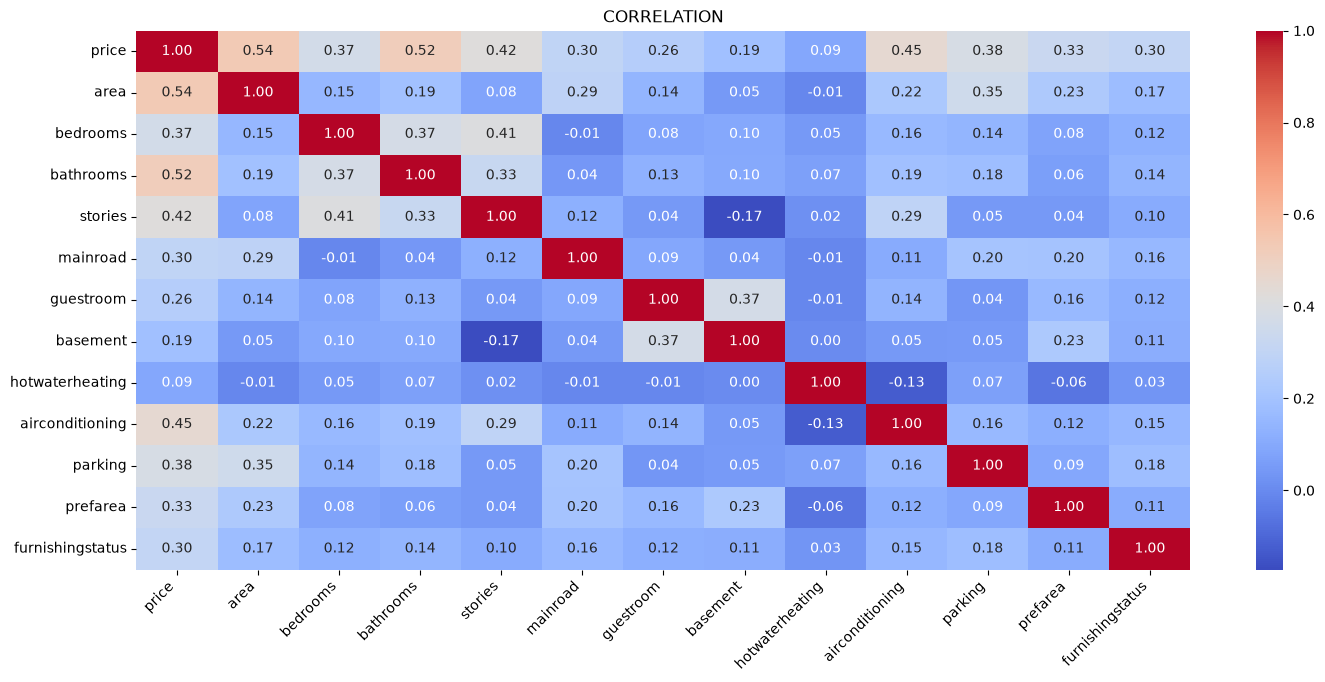

In [82]:
#correlation
plt.figure(figsize=(17,7))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.xticks(rotation=45,ha='right')
plt.title("CORRELATION")
plt.show()


In [83]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,3
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,3
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,3
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,3


# train - test split

In [84]:
from sklearn.model_selection import train_test_split

X= df.drop('price',axis=1)
y= df['price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# feature transformation

In [89]:
#standardization and normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
minmax_scalar = MinMaxScaler()
X_train_scaled = minmax_scalar.fit_transform(X_train)
X_test_scaled = minmax_scalar.transform(X_test)

In [90]:
X_train_scaled

array([[0.29896907, 0.4       , 0.33333333, ..., 0.33333333, 0.        ,
        1.        ],
       [0.3814433 , 0.4       , 0.33333333, ..., 1.        , 0.        ,
        0.5       ],
       [0.14886598, 0.2       , 0.        , ..., 0.66666667, 0.        ,
        1.        ],
       ...,
       [0.19587629, 0.4       , 0.33333333, ..., 0.33333333, 0.        ,
        1.        ],
       [0.16426117, 0.2       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.26460481, 0.4       , 0.33333333, ..., 0.33333333, 0.        ,
        0.5       ]], shape=(436, 12))

# model building

In [93]:
# linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[3431599.63, 392872.46,3291351.8 ,..., 677269.54, 629901.66, 420794.24]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.843e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[12.09,10.05, 8.53,..., 3.18, 2.63, 2.44]"


In [94]:
y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

from sklearn.metrics import mean_squared_error ,mean_absolute_error
mse_test= mean_squared_error(y_test,y_pred_test)
mae_test= mean_absolute_error(y_test,y_pred_test)

mse_train= mean_squared_error(y_train,y_pred_train)
mae_train=mean_absolute_error(y_train,y_pred_train)

print("Test MSE: ",mse_test)
print("Test MAE: ",mae_test)
print("Train MSE: ",mse_train)
print("Train MAE: ",mae_train)


Test MSE:  1771751116594.0408
Test MAE:  979679.6912959908
Train MSE:  969902818698.3114
Train MAE:  718146.5977537852


In [95]:
model.coef_

array([3431599.62951732,  392872.461938  , 3291351.79844388,
       1218669.49338865,  366824.19239248,  233146.76562655,
        393159.77872584,  687881.31095701,  785550.57929543,
        677269.54192885,  629901.66084591,  420794.23654311])

In [96]:
column= X.columns.tolist()

In [97]:
model_coef = model.coef_.tolist()

In [101]:
for col, coef in zip(column,model_coef):
    print(f"Features: {col} , Coefficient: {coef}")
print("\nIntercept: ",model.intercept_)

Features: area , Coefficient: 3431599.6295173247
Features: bedrooms , Coefficient: 392872.46193800116
Features: bathrooms , Coefficient: 3291351.7984438757
Features: stories , Coefficient: 1218669.493388651
Features: mainroad , Coefficient: 366824.1923924804
Features: guestroom , Coefficient: 233146.76562654847
Features: basement , Coefficient: 393159.7787258384
Features: hotwaterheating , Coefficient: 687881.3109570142
Features: airconditioning , Coefficient: 785550.5792954284
Features: parking , Coefficient: 677269.5419288458
Features: prefarea , Coefficient: 629901.6608459108
Features: furnishingstatus , Coefficient: 420794.23654311144

Intercept:  1843354.2290564496
